ASSIGNMENT 7


In [1]:
pip install qiskit qiskit-aer

In [2]:
import numpy as np

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Statevector, random_statevector
from qiskit.circuit.library import Initialize
from qiskit.visualization import plot_histogram, plot_bloch_multivector, array_to_latex
from qiskit_aer import AerSimulator

from IPython.display import display

Experiment 1

In [3]:
!pip install pylatexenc

Message = 00, Counts = {'00': 1024}


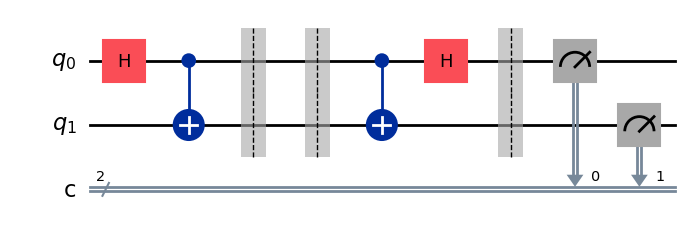

Message = 01, Counts = {'10': 1024}


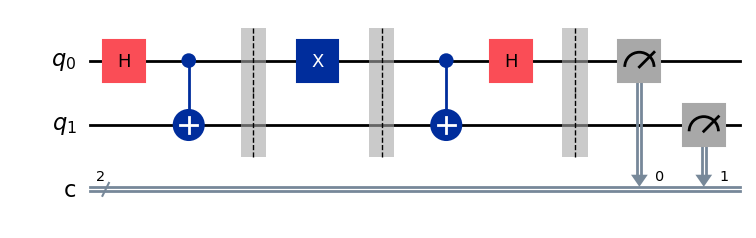

Message = 10, Counts = {'01': 1024}


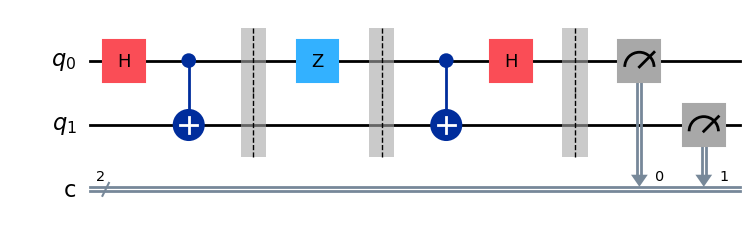

Message = 11, Counts = {'11': 1024}


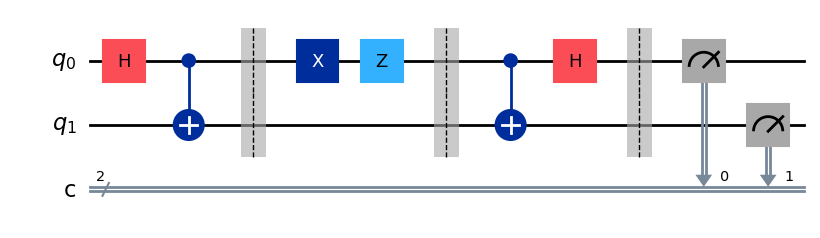

In [4]:
from qiskit.visualization import plot_histogram
def create_bell_pair():
    """Create a Bell pair between qubit 0 and qubit 1."""
    qc = QuantumCircuit(2, 2)
    qc.h(0)
    qc.cx(0, 1)
    return qc

def encode_message(qc, msg, alice_qubit=0):
    """
    Encode 2 classical bits into 1 qubit using superdense coding.

    Bit convention:
      msg[0] -> Z gate
      msg[1] -> X gate
    """
    if len(msg) != 2 or any(bit not in "01" for bit in msg):
        raise ValueError("Message must be a 2-bit string like '00', '01', '10', or '11'.")

    if msg[1] == "1":
        qc.x(alice_qubit)
    if msg[0] == "1":
        qc.z(alice_qubit)

def decode_message(qc):
    """Bob decodes the message."""
    qc.cx(0, 1)
    qc.h(0)

def build_superdense_coding_circuit(message):
    qc = create_bell_pair()
    qc.barrier()

    # Alice encodes her 2-bit message on qubit 0
    encode_message(qc, message, alice_qubit=0)
    qc.barrier()

    # Bob decodes
    decode_message(qc)
    qc.barrier()

    qc.measure([0, 1], [0, 1])
    return qc

# Try all possible messages
messages = ["00", "01", "10", "11"]
sim = AerSimulator()

for msg in messages:
    qc = build_superdense_coding_circuit(msg)
    tqc = transpile(qc, sim)
    result = sim.run(tqc, shots=1024).result()
    counts = result.get_counts()
    print(f"Message = {msg}, Counts = {counts}")
    display(qc.draw("mpl"))
    plot_histogram(counts)

Experiment 2

<IPython.core.display.Latex object>

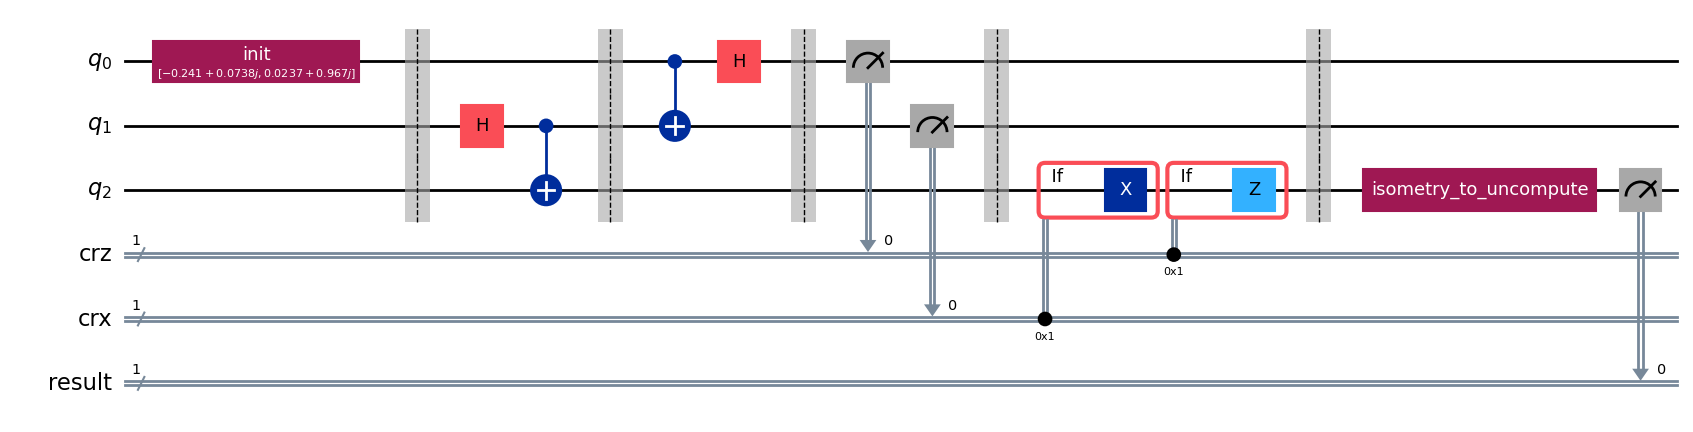

Teleportation counts: {'0 0 1': 272, '0 1 0': 254, '0 0 0': 263, '0 1 1': 235}


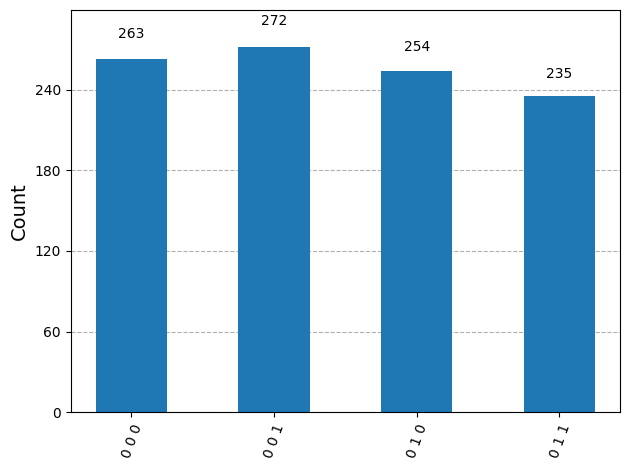

In [5]:
def create_bell_pair_teleport(qc, a, b):
    qc.h(a)
    qc.cx(a, b)

def alice_gates(qc, psi, a):
    qc.cx(psi, a)
    qc.h(psi)

def bob_gates(qc, qubit, crx, crz):
    # Modern conditional control flow
    with qc.if_test((crx, 1)):
        qc.x(qubit)
    with qc.if_test((crz, 1)):
        qc.z(qubit)

# Prepare a random single-qubit state |psi>
psi = random_statevector(2)
display(array_to_latex(psi, prefix="|\\psi\\rangle = "))
plot_bloch_multivector(psi)

# Build teleportation circuit
qr = QuantumRegister(3, "q")
crz = ClassicalRegister(1, "crz")
crx = ClassicalRegister(1, "crx")
qc = QuantumCircuit(qr, crz, crx)

# Initialize qubit 0 to |psi>
init_gate = Initialize(psi)
init_gate.label = "init"
qc.append(init_gate, [0])
qc.barrier()

# Create entanglement between qubits 1 and 2
create_bell_pair_teleport(qc, 1, 2)
qc.barrier()

# Alice's operations
alice_gates(qc, 0, 1)
qc.barrier()

# Alice measures and sends 2 classical bits
qc.measure(0, crz)
qc.measure(1, crx)
qc.barrier()

# Bob corrects qubit 2
bob_gates(qc, 2, crx, crz)
qc.barrier()

# Uncompute the original state on qubit 2 to verify teleportation
inverse_init_gate = init_gate.gates_to_uncompute()
qc.append(inverse_init_gate, [2])

# Measure Bob's qubit
cr_result = ClassicalRegister(1, "result")
qc.add_register(cr_result)
qc.measure(2, cr_result[0])

display(qc.draw("mpl"))

# Run on simulator
sim = AerSimulator()
tqc = transpile(qc, sim)
result = sim.run(tqc, shots=1024).result()
counts = result.get_counts()

print("Teleportation counts:", counts)
plot_histogram(counts)

Experiment 3


Classical coin toss: {'0': 519, '1': 505}
Quantum game vs I: {'0': 1024}


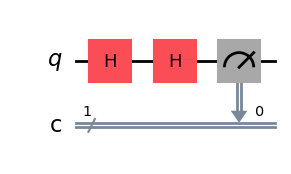

Quantum game vs X: {'0': 1024}


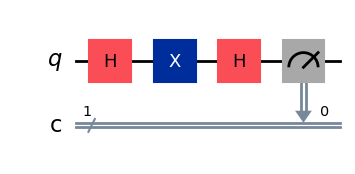

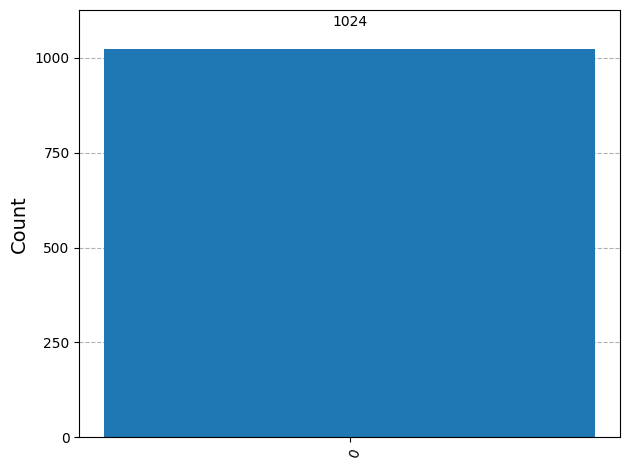

In [6]:
def classical_coin_toss(shots=1024):
    # Pure classical baseline
    tosses = np.random.randint(0, 2, shots)
    heads = int(np.sum(tosses == 0))
    tails = int(np.sum(tosses == 1))
    return {"0": heads, "1": tails}

def quantum_coin_game(opponent_move="x", shots=1024):
    """
    Quantum penny flip game:
    Qubit starts at |0>
    Quantum player applies H
    Classical player applies I or X
    Quantum player applies H again
    Measure
    """
    qc = QuantumCircuit(1, 1)

    # Quantum player's move
    qc.h(0)

    # Classical player's move
    if opponent_move == "x":
        qc.x(0)
    elif opponent_move != "i":
        raise ValueError("opponent_move must be 'i' or 'x'.")

    # Quantum player's winning move
    qc.h(0)

    qc.measure(0, 0)
    return qc

sim = AerSimulator()

# Classical coin toss
classical_counts = classical_coin_toss(1024)
print("Classical coin toss:", classical_counts)
plot_histogram(classical_counts)

# Quantum coin game against I
qc_i = quantum_coin_game(opponent_move="i")
tqc_i = transpile(qc_i, sim)
res_i = sim.run(tqc_i, shots=1024).result().get_counts()
print("Quantum game vs I:", res_i)
display(qc_i.draw("mpl"))
plot_histogram(res_i)

# Quantum coin game against X
qc_x = quantum_coin_game(opponent_move="x")
tqc_x = transpile(qc_x, sim)
res_x = sim.run(tqc_x, shots=1024).result().get_counts()
print("Quantum game vs X:", res_x)
display(qc_x.draw("mpl"))
plot_histogram(res_x)